In [39]:
import torch
from transformers import LayoutLMv3ImageProcessor, LayoutLMv3ForTokenClassification, LayoutLMv3TokenizerFast, AutoModelForTokenClassification
from datasets import load_dataset
from PIL import Image
from io import BytesIO
import re
import requests
import pytesseract

In [35]:
# Load the processor and model
processor = LayoutLMv3ImageProcessor.from_pretrained("nielsr/layoutlmv3-finetuned-cord")
model = LayoutLMv3ForTokenClassification.from_pretrained("nielsr/layoutlmv3-finetuned-cord")
# model = AutoModelForTokenClassification.from_pretrained("nielsr/layoutlmv3-finetuned-cord")
tokenizer = LayoutLMv3TokenizerFast.from_pretrained("nielsr/layoutlmv3-finetuned-cord")

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RobertaTokenizer'. 
The class this function is called from is 'LayoutLMv3TokenizerFast'.


In [36]:
# Set the device
device = "cuda" if torch.cuda.is_available() else "mps"
model.to(device)

LayoutLMv3ForTokenClassification(
  (layoutlmv3): LayoutLMv3Model(
    (embeddings): LayoutLMv3TextEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (x_position_embeddings): Embedding(1024, 128)
      (y_position_embeddings): Embedding(1024, 128)
      (h_position_embeddings): Embedding(1024, 128)
      (w_position_embeddings): Embedding(1024, 128)
    )
    (patch_embed): LayoutLMv3PatchEmbeddings(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (encoder): LayoutLMv3Encoder

In [29]:
# Get Open Food Facts dataset
image_prefix_url = "https://prices.openfoodfacts.org/img/"
dataset = load_dataset("hf-internal-testing/example-documents", split="test")
dataset_ofp = load_dataset("openfoodfacts/open-prices")['prices']
dataset_ofp = dataset_ofp.filter(lambda x: x['proof_type'] == 'RECEIPT')
image_url = image_prefix_url+dataset_ofp[0]['proof_file_path']
response = requests.get(image_url)
response.raise_for_status()
image = Image.open(BytesIO(response.content))
# image = dataset[2]["image"]
image.show()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [49]:
# Preprocess the image

# # Extract text from the image using OCR
extracted_text = pytesseract.image_to_string(image)
words = extracted_text.split()

encoding = processor(image, return_tensors="pt")
# encoding = processor(image, words,return_tensors="pt")
pixel_values = encoding["pixel_values"].to(device)

# Tokenize the text and bounding boxes (CRUCIAL STEP)
encoded_inputs = tokenizer(words,return_tensors="pt", padding="max_length", truncation=True) #added padding and truncation



# print(words)
# # Tokenize the input image to get input IDs
# inputs = tokenizer(words, return_tensors="pt", is_split_into_words=True)
# input_ids = inputs["input_ids"].to(device)
#
# # Get the embeddings from the tokenizer
# inputs_embeds = model.get_input_embeddings()(input_ids)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


ValueError: You must provide corresponding bounding boxes

In [48]:
# Perform inference
with torch.no_grad():
    outputs = model(pixel_values=pixel_values)
    logits = outputs.logits

# Get the predicted class labels
predicted_class_indices = logits.argmax(-1).squeeze().tolist()
labels = [tokenizer.decode([idx]) for idx in predicted_class_indices]

# Print the results
print(labels)

/opt/homebrew/Caskroom/miniforge/base/envs/ml-cli/lib/python3.12/site-packages/transformers/modeling_utils.py:1161: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


AttributeError: 'NoneType' object has no attribute 'size'

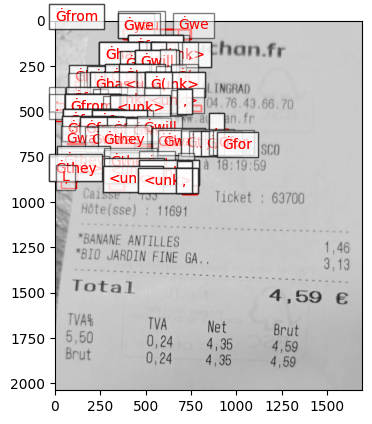

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Display the image
fig, ax = plt.subplots(1)
ax.imshow(image)

# Get the bounding boxes and labels
bboxes = encoding["bbox"].squeeze().tolist()
labels = tokenizer.convert_ids_to_tokens(predicted_class_indices)

# Plot the bounding boxes and labels
for bbox, label in zip(bboxes, labels):
    if label != "[PAD]":
        x, y, w, h = bbox[0], bbox[1], bbox[2] - bbox[0], bbox[3] - bbox[1]
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        plt.text(x, y, label, color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

plt.show()